# Reprogramming Case 02: Neuronal TF Screening with Navigo

This notebook reproduces the neuronal reprogramming analysis described in the Navigo study.

Training note: **`checkpoint_neural_repro` is trained using fibroblasts and neurons together**, so the model captures lineage transitions relevant to fibroblast-to-neuron conversion.

Biological objective:
- Start from fibroblasts and evaluate which TFs or TF pairs can move cells toward neuronal programs.
- Prioritize candidates by directional agreement between predicted perturbation response and expected fibroblast-to-neuron expression shifts.
- Benchmark against experimental pairwise screening of bHLH and POU families.

This mirrors the manuscript strategy for evaluating both single-factor potential and pairwise combinatorial effects.

Import packages and set deterministic seeds to keep screening outputs reproducible.

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import anndata
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from scipy.stats import spearmanr
import torch

plt.rcParams['figure.dpi'] = 120
np.random.seed(0)
torch.manual_seed(0)


Configure source data paths and define organized outputs for this neuronal screening case.

Biological context: `checkpoint_neural_repro.pth` is the fibroblast+neuron trained model used for neuronal conversion screening.

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'docs' / 'tutorials').exists() and (p / 'navigo').exists():
            return p
    raise RuntimeError(f'Could not locate repository root from {start}')


cwd = Path.cwd().resolve()
repo_root = find_repo_root(cwd)
tutorials_root = repo_root / 'docs' / 'tutorials'
notebook_dir = tutorials_root / 'notebooks' / 'reprogramming_section'
data_shared_dir = repo_root / 'data' / 'shared'
data_repro_dir = repo_root / 'data' / 'reprogramming'
case_output_root = tutorials_root / 'outputs' / 'reprogramming_neuron_screening'

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from navigo import run_perturbation_inference

CHECKPOINT_PATH = repo_root / 'checkpoints' / 'reprogramming' / 'neural_reprogramming_checkpoint.pth'
DATA_PATH = data_shared_dir / 'mouse_heart_fibroblasts.h5ad'
TARGET_LIST_PATH = data_repro_dir / 'neuron_screen_targets.csv'
METRICS_PATH = tutorials_root / 'resources' / 'reprogramming' / 'neuron_screen_metrics.csv'
GROUNDTRUTH_PATH = data_repro_dir / 'neuron_screen_groundtruth.csv'
SINGLE_METRICS_PATH = tutorials_root / 'resources' / 'reprogramming' / 'neuron_screen_bhlh_metrics.csv'

RERUN_DIR = case_output_root / '01_inference_csv'
OUTPUT_DIR = case_output_root / '02_metrics_tables'
PLOT_DIR = case_output_root / '03_figures'

MAX_TARGETS = None
FLOW_NUM_STEPS = 100
SIMULATION_STEPS = 10
KNOCKOUT_SCALE = 3.0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

for name, pth in {
    'checkpoint': CHECKPOINT_PATH,
    'data': DATA_PATH,
    'target_list': TARGET_LIST_PATH,
    'metrics': METRICS_PATH,
    'groundtruth': GROUNDTRUTH_PATH,
    'single_metrics': SINGLE_METRICS_PATH,
}.items():
    if not pth.exists():
        raise FileNotFoundError(f'Missing required {name}: {pth}')

RERUN_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(json.dumps({
    'tutorial_root': str(tutorials_root.relative_to(repo_root)),
    'notebook_dir': str(notebook_dir.relative_to(repo_root)),
    'case_output_root': str(case_output_root.relative_to(repo_root)),
    'device': DEVICE,
    'max_targets': MAX_TARGETS,
}, indent=2))


{
  "tutorial_root": "docs/tutorials",
  "notebook_dir": "docs/tutorials/notebooks/reprogramming_section",
  "case_output_root": "docs/tutorials/outputs/reprogramming_neuron_screening",
  "device": "cuda",
  "max_targets": null
}


## In silico perturbation screen of candidate neuronal factors

We simulate fibroblast perturbations for each candidate TF and store predicted expression responses.

In [3]:
all_target_lines = [ln.strip() for ln in TARGET_LIST_PATH.read_text().splitlines() if ln.strip()]
target_lines = all_target_lines[:MAX_TARGETS] if MAX_TARGETS is not None else all_target_lines

targets_used_path = RERUN_DIR / 'targets_used.csv'
targets_used_path.write_text('\n'.join(target_lines) + '\n')

inference_summary = run_perturbation_inference(
    data_path=DATA_PATH,
    checkpoint_path=CHECKPOINT_PATH,
    target_list_path=targets_used_path,
    output_dir=RERUN_DIR,
    fibro_cell_type='Fibroblasts',
    input_dim=7804,
    hidden_1=5012,
    hidden_2=5012,
    flow_num_steps=FLOW_NUM_STEPS,
    simulation_steps=SIMULATION_STEPS,
    knockout_scale=KNOCKOUT_SCALE,
    device=DEVICE,
    strict_target_presence=True,
)
print(json.dumps(inference_summary, indent=2))


Perturbation inference:   0%|          | 0/192 [00:00<?, ?it/s]

Perturbation inference:   1%|          | 1/192 [00:12<40:51, 12.84s/it]

Perturbation inference:   1%|          | 2/192 [00:23<37:17, 11.77s/it]

Perturbation inference:   2%|▏         | 3/192 [00:34<34:51, 11.06s/it]

Perturbation inference:   2%|▏         | 4/192 [00:46<36:41, 11.71s/it]

...

Perturbation inference:  99%|█████████▉| 190/192 [34:05<00:16,  8.02s/it]

Perturbation inference:  99%|█████████▉| 191/192 [34:15<00:08,  8.85s/it]

Perturbation inference: 100%|██████████| 192/192 [34:29<00:00, 10.18s/it]

Perturbation inference: 100%|██████████| 192/192 [34:29<00:00, 10.78s/it]

{
  "data_path": "/workspace/fuchenghao/Navigo_unified_repo/data/shared/mouse_heart_fibroblasts.h5ad",
  "checkpoint_path": "/workspace/fuchenghao/Navigo_unified_repo/checkpoints/reprogramming/neural_reprogramming_checkpoint.pth",
  "target_list_path": "/workspace/fuchenghao/Navigo_unified_repo/docs/tutorials/outputs/reprogramming_neuron_screening/01_inference_csv/targets_used.csv",
  "output_dir": "/workspace/fuchenghao/Navigo_unified_repo/docs/tutorials/outputs/reprogramming_neuron_screening/01_inference_csv",
  "device": "cuda",
  "num_cells_fibro": 6711,
  "num_targets": 192,
  "num_outputs": 192,
  "missing_targets_unique": [],
  "flow_num_steps": 100,
  "simulation_steps": 10,
  "knockout_scale": 3.0,
  "elapsed_sec": 2164.9405064582825
}


## Quantitative evaluation against experimental combinatorial maps

Following the manuscript (Methods, Eq. 30-32), we compute directional alignment scores and AUROC across programming-effect and expression thresholds.

In [4]:
adata = anndata.read_h5ad(DATA_PATH)
adata = adata[adata.obs['cell_type'].astype(str) == 'Fibroblasts'].copy()

joint = np.concatenate([adata.layers['Ms'], adata.layers['Mu']], axis=1)
joint = (joint - joint.min(axis=0)) / (joint.max(axis=0) - joint.min(axis=0) + 1e-7)
num_genes = joint.shape[1] // 2
expression = (joint[:, :num_genes] + joint[:, num_genes:]).mean(axis=0)

adata_gene_names = adata.var['gene_name'].astype(str).to_numpy() if 'gene_name' in adata.var.columns else adata.var_names.astype(str).to_numpy()

df_insilico = pd.read_csv(METRICS_PATH, index_col=0)
df_real = pd.read_csv(GROUNDTRUTH_PATH, index_col=0)

genes = set(df_real.index) | set(df_real.columns)
gene_name_set = set(adata_gene_names)
gene_expr = {
    g: float(expression[np.where(adata_gene_names == g)[0][0]])
    for g in genes
    if g in gene_name_set
}
expression_df = pd.DataFrame.from_dict(gene_expr, orient='index', columns=['expression'])

df_split = df_insilico.index.to_series().str.split('_', expand=True)
df_insilico[['tf1', 'tf2']] = df_split
heatmap_data_full = df_insilico.pivot(index='tf1', columns='tf2', values='avg_accuracy').reindex(index=df_real.index, columns=df_real.columns)

exclude_genes = ['Pou3f4', 'Pou2f1', 'Pou2f3', 'Pou6f1']
heatmap_data_full = heatmap_data_full[~heatmap_data_full.index.isin(exclude_genes)]
df_real_full = df_real[~df_real.index.isin(exclude_genes)]

thresholds = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
min_expr_values = [0, 0.01, 0.02, 0.015, 0.005]
calc_auc = lambda y_true, y_score: auc(*roc_curve(y_true, y_score)[:2]) if len(np.unique(y_true)) > 1 else None

rows = []
for threshold in thresholds:
    for min_expr in min_expr_values:
        expr_mask = lambda g: expression_df.loc[g, 'expression'] >= min_expr
        hm = heatmap_data_full.loc[expr_mask(heatmap_data_full.index), expr_mask(heatmap_data_full.columns)]
        gt = df_real_full.loc[expr_mask(df_real_full.index), expr_mask(df_real_full.columns)]

        y_true = (gt > threshold).values.flatten()
        y_score = hm.values.flatten()
        fpr, tpr, _ = roc_curve(y_true, y_score)
        overall_auc = float(auc(fpr, tpr))

        pd.DataFrame({'fpr': fpr, 'tpr': tpr}).to_csv(OUTPUT_DIR / f'02_roc_curve_thr_{threshold}_minexpr_{min_expr}.csv', index=False)

        tf_rows = []
        for gene in gt.index:
            gene_auc = calc_auc((gt.loc[gene] > threshold).astype(int), hm.loc[gene])
            if gene_auc is not None:
                tf_rows.append({'gene': gene, 'auroc': float(gene_auc), 'expression': float(expression_df.loc[gene, 'expression'])})

        target_rows = []
        for gene in gt.columns:
            gene_auc = calc_auc((gt[gene] > threshold).astype(int), hm[gene])
            if gene_auc is not None:
                target_rows.append({'gene': gene, 'auroc': float(gene_auc), 'expression': float(expression_df.loc[gene, 'expression'])})

        tf_df = pd.DataFrame(tf_rows)
        target_df = pd.DataFrame(target_rows)

        tf_df.to_csv(OUTPUT_DIR / f'02_tf_auroc_expression_thr_{threshold}_minexpr_{min_expr}.csv', index=False)
        target_df.to_csv(OUTPUT_DIR / f'02_target_auroc_expression_thr_{threshold}_minexpr_{min_expr}.csv', index=False)

        tf_corr, tf_p = spearmanr(tf_df['auroc'], tf_df['expression']) if len(tf_df) > 1 else (np.nan, np.nan)
        target_corr, target_p = spearmanr(target_df['auroc'], target_df['expression']) if len(target_df) > 1 else (np.nan, np.nan)

        rows.append({
            'threshold': threshold,
            'min_expr': min_expr,
            'overall_auc': overall_auc,
            'tf_corr': float(tf_corr) if not np.isnan(tf_corr) else np.nan,
            'tf_pval': float(tf_p) if not np.isnan(tf_p) else np.nan,
            'tf_count': int(len(tf_df)),
            'target_corr': float(target_corr) if not np.isnan(target_corr) else np.nan,
            'target_pval': float(target_p) if not np.isnan(target_p) else np.nan,
            'target_count': int(len(target_df)),
            'matrix_rows': int(hm.shape[0]),
            'matrix_cols': int(hm.shape[1]),
        })

summary_df = pd.DataFrame(rows)
summary_df.to_csv(OUTPUT_DIR / '02_summary_all_thresholds.csv', index=False)
summary_df.pivot(index='threshold', columns='min_expr', values='overall_auc').to_csv(OUTPUT_DIR / '02_heatmap_overall_auroc.csv')
summary_df.pivot(index='threshold', columns='min_expr', values='tf_corr').to_csv(OUTPUT_DIR / '02_heatmap_tf_spearman.csv')
summary_df.pivot(index='threshold', columns='min_expr', values='target_corr').to_csv(OUTPUT_DIR / '02_heatmap_target_spearman.csv')

print('Summary rows:', len(summary_df))


Summary rows: 30


/tmp/ipykernel_3064214/2941280949.py:67: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  tf_corr, tf_p = spearmanr(tf_df['auroc'], tf_df['expression']) if len(tf_df) > 1 else (np.nan, np.nan)
/tmp/ipykernel_3064214/2941280949.py:67: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  tf_corr, tf_p = spearmanr(tf_df['auroc'], tf_df['expression']) if len(tf_df) > 1 else (np.nan, np.nan)
/tmp/ipykernel_3064214/2941280949.py:68: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  target_corr, target_p = spearmanr(target_df['auroc'], target_df['expression']) if len(target_df) > 1 else (np.nan, np.nan)
/tmp/ipykernel_3064214/2941280949.py:67: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  tf_corr, tf_p = spearmanr(tf_df['auroc'], tf_df['expression']) if len(tf_df) > 1 else (np.nan, np.nan)
/tmp/ipykernel_30642

## Robust operating-point selection

We visualize threshold sensitivity and choose a stable high-performing setting for ROC reporting.

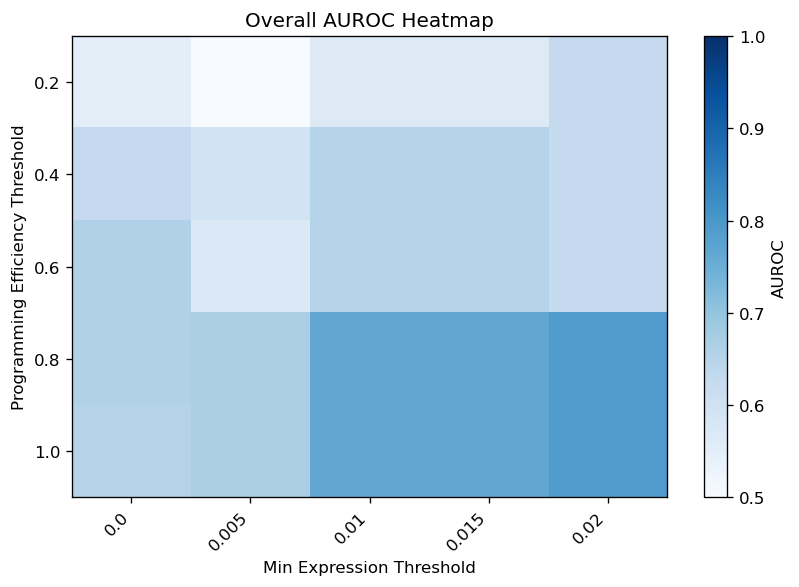

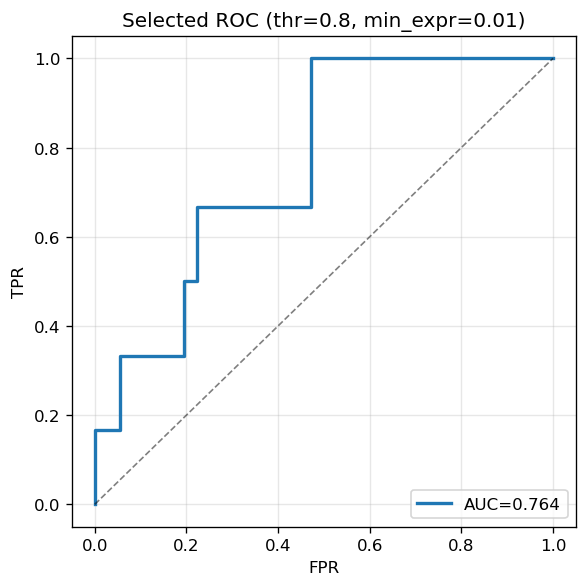

{
  "best_threshold": 0.8,
  "best_min_expr": 0.01,
  "best_overall_auc": 0.7638888888888888,
  "heatmap_pdf": "docs/tutorials/outputs/reprogramming_neuron_screening/03_figures/02_overall_auroc_heatmap.pdf",
  "best_roc_pdf": "docs/tutorials/outputs/reprogramming_neuron_screening/03_figures/02_selected_roc_curve.pdf",
  "summary_csv": "docs/tutorials/outputs/reprogramming_neuron_screening/02_metrics_tables/02_summary_all_thresholds.csv"
}


In [5]:
summary_df = pd.read_csv(OUTPUT_DIR / '02_summary_all_thresholds.csv')
heatmap_df = pd.read_csv(OUTPUT_DIR / '02_heatmap_overall_auroc.csv', index_col=0)

heatmap_df.index = heatmap_df.index.astype(float)
heatmap_plot_df = heatmap_df[heatmap_df.index >= 0.2].copy().sort_index()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(heatmap_plot_df.values, aspect='auto', cmap='Blues', vmin=0.5, vmax=1.0)
ax.set_xticks(np.arange(len(heatmap_plot_df.columns)))
ax.set_xticklabels([str(c) for c in heatmap_plot_df.columns], rotation=45, ha='right')
ax.set_yticks(np.arange(len(heatmap_plot_df.index)))
ax.set_yticklabels([f'{v:.1f}' for v in heatmap_plot_df.index])
ax.set_xlabel('Min Expression Threshold')
ax.set_ylabel('Programming Efficiency Threshold')
ax.set_title('Overall AUROC Heatmap')
cbar = fig.colorbar(im, ax=ax, label='AUROC')
cbar.set_ticks(np.linspace(0.5, 1.0, 6))
plt.tight_layout()
heatmap_pdf = PLOT_DIR / '02_overall_auroc_heatmap.pdf'
fig.savefig(heatmap_pdf, bbox_inches='tight')
plt.show()

stable = summary_df[(summary_df['threshold'] >= 0.2) & (summary_df['tf_count'] >= 3) & (summary_df['target_count'] >= 2)].copy()
if stable.empty:
    best_row = summary_df[summary_df['threshold'] >= 0.2].sort_values('overall_auc', ascending=False).iloc[0]
else:
    best_row = stable.sort_values(by=['overall_auc', 'threshold', 'min_expr'], ascending=[False, True, True]).iloc[0]

best_thr = float(best_row['threshold'])
best_min_expr = float(best_row['min_expr'])
roc_df = pd.read_csv(OUTPUT_DIR / f'02_roc_curve_thr_{best_thr}_minexpr_{best_min_expr}.csv')

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(roc_df['fpr'], roc_df['tpr'], linewidth=2, label=f"AUC={best_row['overall_auc']:.3f}")
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'Selected ROC (thr={best_thr}, min_expr={best_min_expr})')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
roc_pdf = PLOT_DIR / '02_selected_roc_curve.pdf'
fig.savefig(roc_pdf, bbox_inches='tight')
plt.show()

results = {
    'best_threshold': best_thr,
    'best_min_expr': best_min_expr,
    'best_overall_auc': float(best_row['overall_auc']),
    'heatmap_pdf': str(heatmap_pdf.relative_to(repo_root)),
    'best_roc_pdf': str(roc_pdf.relative_to(repo_root)),
    'summary_csv': str((OUTPUT_DIR / '02_summary_all_thresholds.csv').relative_to(repo_root)),
}
(OUTPUT_DIR / '02_selection_summary.json').write_text(json.dumps(results, indent=2))
print(json.dumps(results, indent=2))


## Single-family bHLH prioritization

This section ranks individual bHLH factors and highlights candidates that overlap with experimentally validated neuronal inducers.

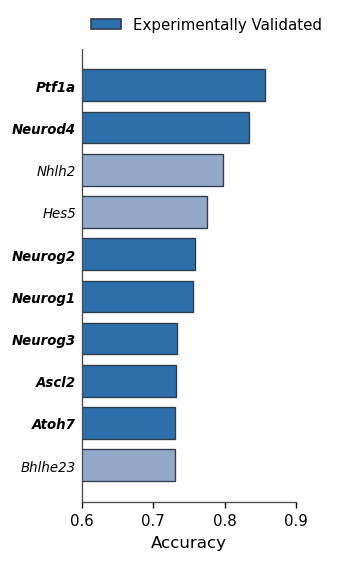

{
  "single_screen_auroc": 0.6632653061224489,
  "single_ranking_csv": "docs/tutorials/outputs/reprogramming_neuron_screening/02_metrics_tables/02_single_ranking_top10.csv",
  "single_ranking_plot": "docs/tutorials/outputs/reprogramming_neuron_screening/03_figures/02_single_screen_ranking.pdf"
}


In [6]:
# Single-screen ranking (aligned with plot_single_screen.py)
from sklearn.metrics import roc_auc_score

single_pred_path = SINGLE_METRICS_PATH
if not single_pred_path.exists():
    raise FileNotFoundError(f'Missing metrics file: {single_pred_path}')

df_real = pd.read_csv(GROUNDTRUTH_PATH, index_col=0)
df_pred = pd.read_csv(single_pred_path)

valid_targets = set(df_real.columns[(df_real != 0).sum() > 0])
all_labels = np.array([1 if tf in valid_targets else 0 for tf in df_pred['tf']])

single_auroc = float(roc_auc_score(all_labels, df_pred['avg_accuracy']))

df_top10 = df_pred.head(10).copy()
df_top10['label'] = all_labels[:10]

single_csv = OUTPUT_DIR / '02_single_ranking_top10.csv'
df_top10.to_csv(single_csv, index=False)

# Plot style follows the provided reference screenshot.
fig, ax = plt.subplots(figsize=(2.3, 4.9))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

y = np.arange(len(df_top10))
colors = ['#2c6faa' if int(v) == 1 else '#93a9c9' for v in df_top10['label']]
ax.barh(y, df_top10['avg_accuracy'], color=colors, edgecolor='#2f3b4a', linewidth=0.8, height=0.75)

ax.set_yticks(y)
ax.set_yticklabels(df_top10['tf'], fontstyle='italic', fontsize=8)
ax.invert_yaxis()

for tick, label in zip(ax.get_yticklabels(), df_top10['label'].tolist()):
    if int(label) == 1:
        tick.set_fontweight('bold')

ax.set_xlim(0.6, 0.9)
ax.set_xticks([0.6, 0.7, 0.8, 0.9])
ax.set_xlabel('Accuracy', fontsize=10)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', length=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#4c4c4c')
ax.spines['bottom'].set_color('#4c4c4c')

from matplotlib.patches import Patch
legend_patch = Patch(facecolor='#2c6faa', edgecolor='#2f3b4a', label='Experimentally Validated')
ax.legend(handles=[legend_patch], loc='upper left', bbox_to_anchor=(-0.02, 1.10), frameon=False, fontsize=9)

single_plot_pdf = PLOT_DIR / '02_single_screen_ranking.pdf'
fig.savefig(single_plot_pdf, bbox_inches='tight')
plt.show()

single_summary = {
    'single_screen_auroc': single_auroc,
    'single_ranking_csv': str(single_csv.relative_to(repo_root)),
    'single_ranking_plot': str(single_plot_pdf.relative_to(repo_root)),
}
(OUTPUT_DIR / '02_single_screen_summary.json').write_text(json.dumps(single_summary, indent=2))
print(json.dumps(single_summary, indent=2))
